<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_3_(Exercise_3_3)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Imports

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Fix seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using: cpu


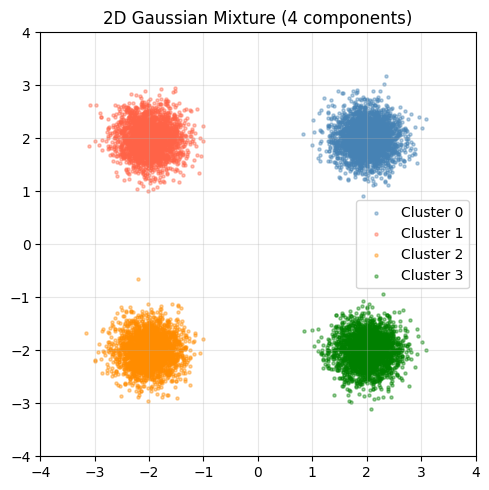

In [2]:
# Data Generation

MEANS  = np.array([[2,2], [-2,2], [-2,-2], [2,-2]], dtype=np.float32)
STD    = 0.3
K      = 4
COLORS = ['steelblue', 'tomato', 'darkorange', 'green']

def sample_gmm(n, means=MEANS, std=STD):
    labels  = np.random.randint(0, K, n)
    samples = means[labels] + std * np.random.randn(n, 2).astype(np.float32)
    return samples, labels

data, labels = sample_gmm(10000)

plt.figure(figsize=(5, 5))
for k in range(K):
    mask = labels == k
    plt.scatter(data[mask, 0], data[mask, 1],
                s=5, alpha=0.4, color=COLORS[k], label=f'Cluster {k}')
plt.title('2D Gaussian Mixture (4 components)')
plt.xlim(-4, 4); plt.ylim(-4, 4)
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_data.png', dpi=150)
plt.show()

In [3]:
# Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas            = betas.to(device)
alpha_bar        = alpha_bar.to(device)

In [4]:
# Model Architecture

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1))
        )
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles),
                          torch.cos(angles)], dim=-1)


class MLPDiffusion(nn.Module):
    def __init__(self, t_emb_dim=64, hidden=256, n_classes=0):
        super().__init__()
        self.t_emb     = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp     = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim),
            nn.SiLU()
        )
        self.n_classes = n_classes

        if n_classes > 0:
            # Class label injected additively into time embedding
            # Equivalent to AdaGN for MLP-based networks
            self.class_emb = nn.Linear(n_classes, t_emb_dim)

        self.net = nn.Sequential(
            nn.Linear(2 + t_emb_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2)   # ε prediction in 2D
        )

    def forward(self, x, t, c=None):
        """
        x: (B, 2)
        t: (B,) timestep indices
        c: (B, K) one-hot class label — optional
        """
        t_emb = self.t_mlp(self.t_emb(t))

        if self.n_classes > 0 and c is not None:
            t_emb = t_emb + self.class_emb(c)

        inp = torch.cat([x, t_emb], dim=-1)
        return self.net(inp)

In [5]:
#  Training

def train_diffusion(model, data, labels=None, epochs=300, batch_size=512):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    data_t = torch.tensor(data, dtype=torch.float32).to(device)
    if labels is not None:
        labels_t = torch.tensor(labels, dtype=torch.long).to(device)

    N = len(data_t)

    for epoch in range(epochs):
        idx        = torch.randperm(N)
        epoch_loss = 0
        n_batches  = 0

        for i in range(0, N, batch_size):
            b_idx = idx[i:i+batch_size]
            x0    = data_t[b_idx]
            B     = x0.shape[0]

            t_idx = torch.randint(0, T, (B,), device=device)
            ab    = alpha_bar[t_idx].unsqueeze(1)

            eps   = torch.randn_like(x0)
            x_t   = (ab ** 0.5) * x0 + ((1 - ab) ** 0.5) * eps

            c = None
            if labels is not None:
                c = torch.zeros(B, K, device=device)
                c.scatter_(1, labels_t[b_idx].unsqueeze(1), 1.0)

            pred  = model(x_t, t_idx, c)
            loss  = criterion(pred, eps)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} "
                  f"— Loss: {epoch_loss/n_batches:.6f}")

    return model


print("Training unconditional model...")
model_uncond = train_diffusion(
    MLPDiffusion(n_classes=0), data, labels=None, epochs=300)

print("\nTraining conditional model...")
model_cond = train_diffusion(
    MLPDiffusion(n_classes=K), data, labels=labels, epochs=300)

print("\nBoth models trained.")

Training unconditional model...
Epoch 100/300 — Loss: 0.243051
Epoch 200/300 — Loss: 0.260120
Epoch 300/300 — Loss: 0.256893

Training conditional model...
Epoch 100/300 — Loss: 0.126734
Epoch 200/300 — Loss: 0.118975
Epoch 300/300 — Loss: 0.122330

Both models trained.


In [6]:
# True Posterior Mean (Analytical)

def true_posterior_mean_grid(x_t_np, t_idx, alpha_bar, betas,
                              means=MEANS, std=STD):
    """
    Analytically compute the marginal true posterior mean
    for a 2D Gaussian mixture at a given timestep.

    x_t_np: (N, 2) grid points
    Returns: (N, 2) true posterior mean μ̃_t(x_t)
    """
    ab      = alpha_bar[t_idx].item()
    b       = betas[t_idx].item()
    a       = 1.0 - b
    ab_prev = alpha_bar[t_idx - 1].item() if t_idx > 0 else 1.0

    # DDPM posterior mean coefficients
    coef1 = (ab_prev ** 0.5 * b)           / (1 - ab)
    coef2 = (a ** 0.5 * (1 - ab_prev))     / (1 - ab)

    sigma2 = std ** 2
    D      = ab * sigma2 + (1 - ab)   # marginal variance per component

    log_probs = []
    x0_means  = []

    for k in range(len(means)):
        mu_k = means[k]   # (2,)

        # E[x_0 | x_t, k] — Bayesian posterior for Gaussians
        gain  = sigma2 * (ab ** 0.5) / D
        x0_k  = mu_k + gain * (x_t_np - (ab ** 0.5) * mu_k)
        x0_means.append(x0_k)

        # log p(x_t | k)
        diff  = x_t_np - (ab ** 0.5) * mu_k
        log_p = -0.5 * np.sum(diff ** 2, axis=1) / D
        log_probs.append(log_p)

    # Posterior weights p(k | x_t)
    log_probs  = np.stack(log_probs, axis=1)           # (N, K)
    log_probs -= log_probs.max(axis=1, keepdims=True)  # numerical stability
    weights    = np.exp(log_probs)
    weights   /= weights.sum(axis=1, keepdims=True)    # (N, K)

    # E[x_0 | x_t] marginalised over components
    x0_mean = sum(weights[:, k:k+1] * x0_means[k]
                  for k in range(len(means)))

    # True posterior mean of x_{t-1}
    mu_true = coef1 * x0_mean + coef2 * x_t_np
    return mu_true

In [7]:
# Model Posterior Mean

def model_posterior_mean_grid(model, x_t_np, t_idx,
                               alpha_bar, betas, c=None):
    """
    Compute the model's posterior mean prediction over grid points.
    x_t_np: (N, 2) numpy array
    c:      (N, K) one-hot tensor on device — optional
    Returns: (N, 2) numpy array
    """
    model.eval()

    ab      = alpha_bar[t_idx].item()
    b       = betas[t_idx].item()
    a       = 1.0 - b
    ab_prev = alpha_bar[t_idx - 1].item() if t_idx > 0 else 1.0

    coef1 = (ab_prev ** 0.5 * b)       / (1 - ab)
    coef2 = (a ** 0.5 * (1 - ab_prev)) / (1 - ab)

    x_t_t = torch.tensor(x_t_np, dtype=torch.float32).to(device)
    t_t   = torch.full((len(x_t_np),), t_idx,
                        dtype=torch.long, device=device)

    with torch.no_grad():
        eps_pred = model(x_t_t, t_t, c).cpu().numpy()

    # Recover x̂_0 from ε prediction
    x0_pred  = (x_t_np - (1 - ab) ** 0.5 * eps_pred) / (ab ** 0.5)

    # Model posterior mean
    mu_theta = coef1 * x0_pred + coef2 * x_t_np
    return mu_theta

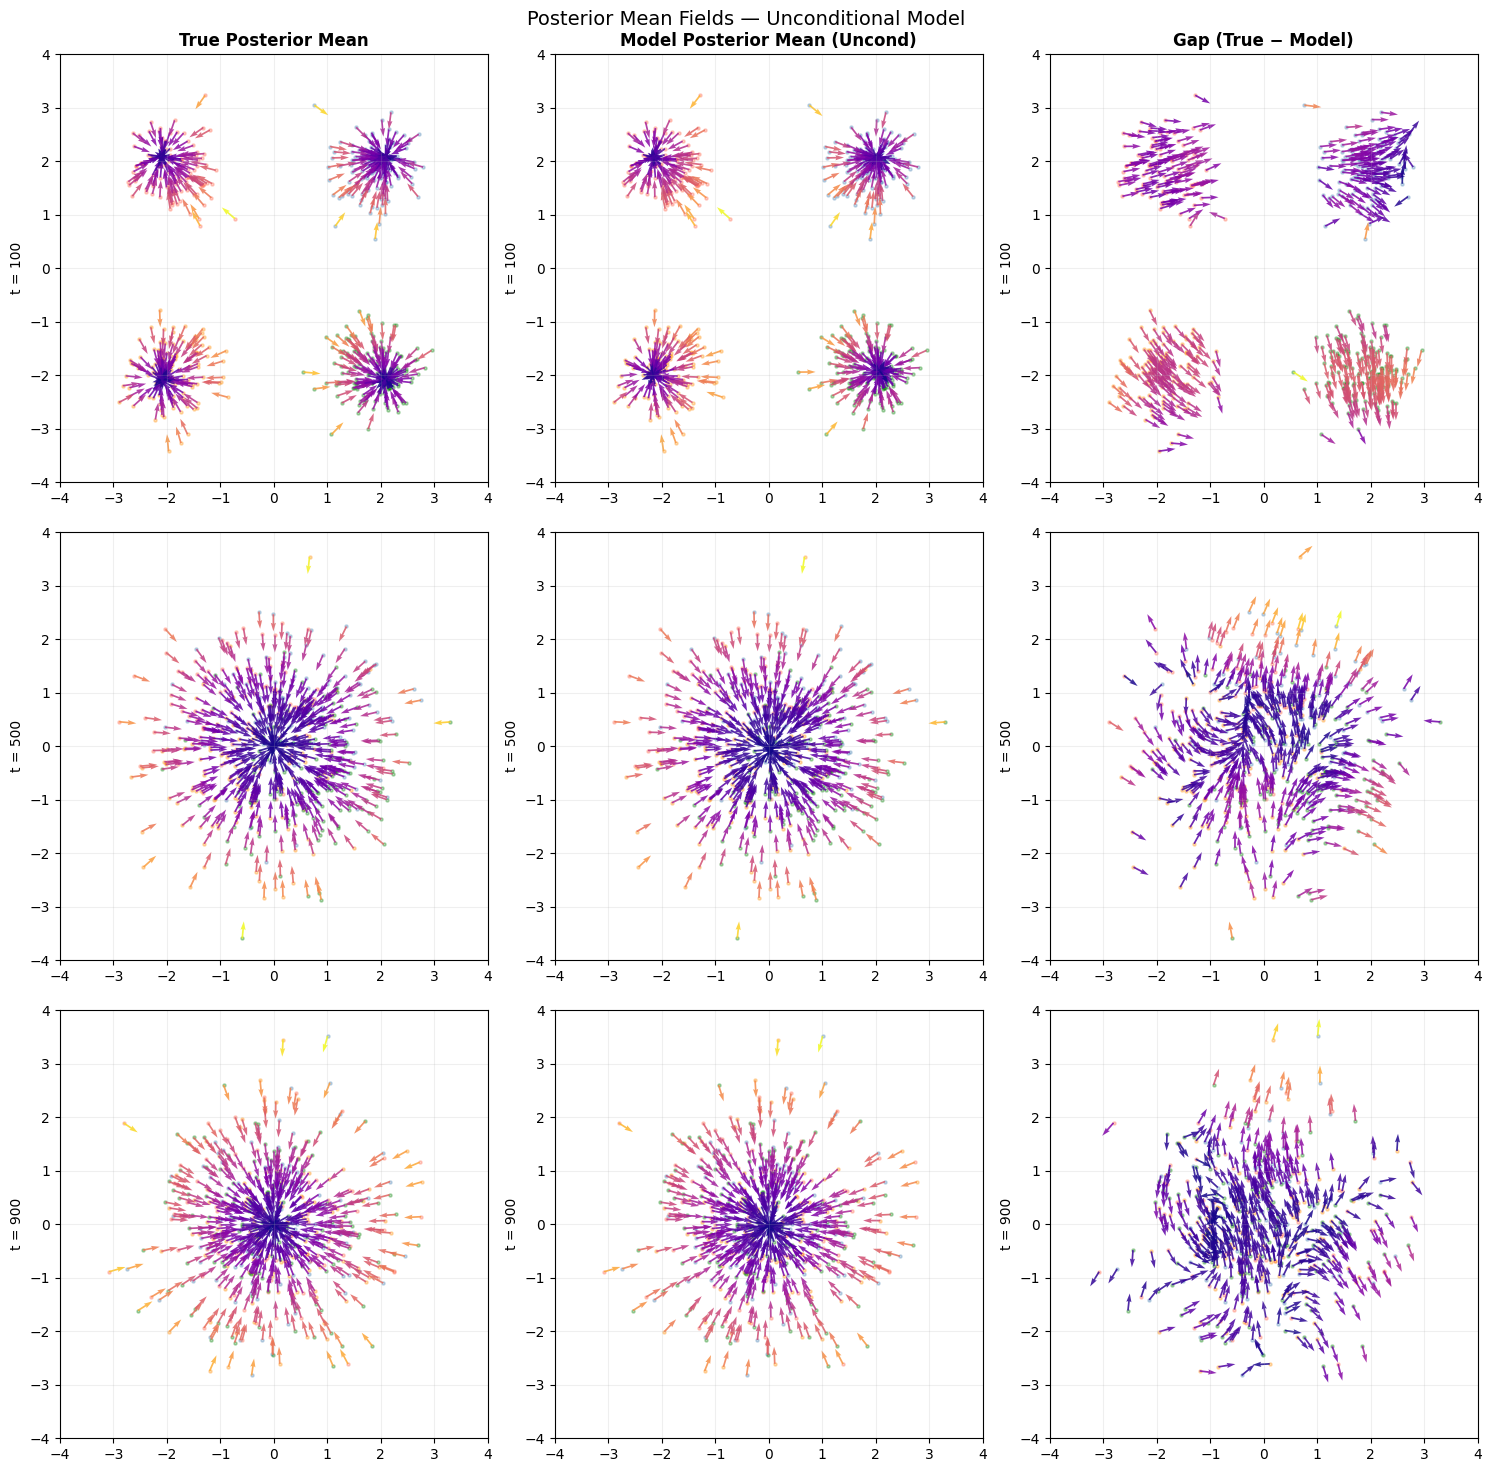


Gap comparison (same x_t for both models):
Timestep       Uncond Gap     Cond Gap    Reduction
----------------------------------------------------
t=100             0.0011       0.0006        44.9%
t=500             0.0003       0.0073     -2092.2%
t=900             0.0005       0.0019      -293.7%


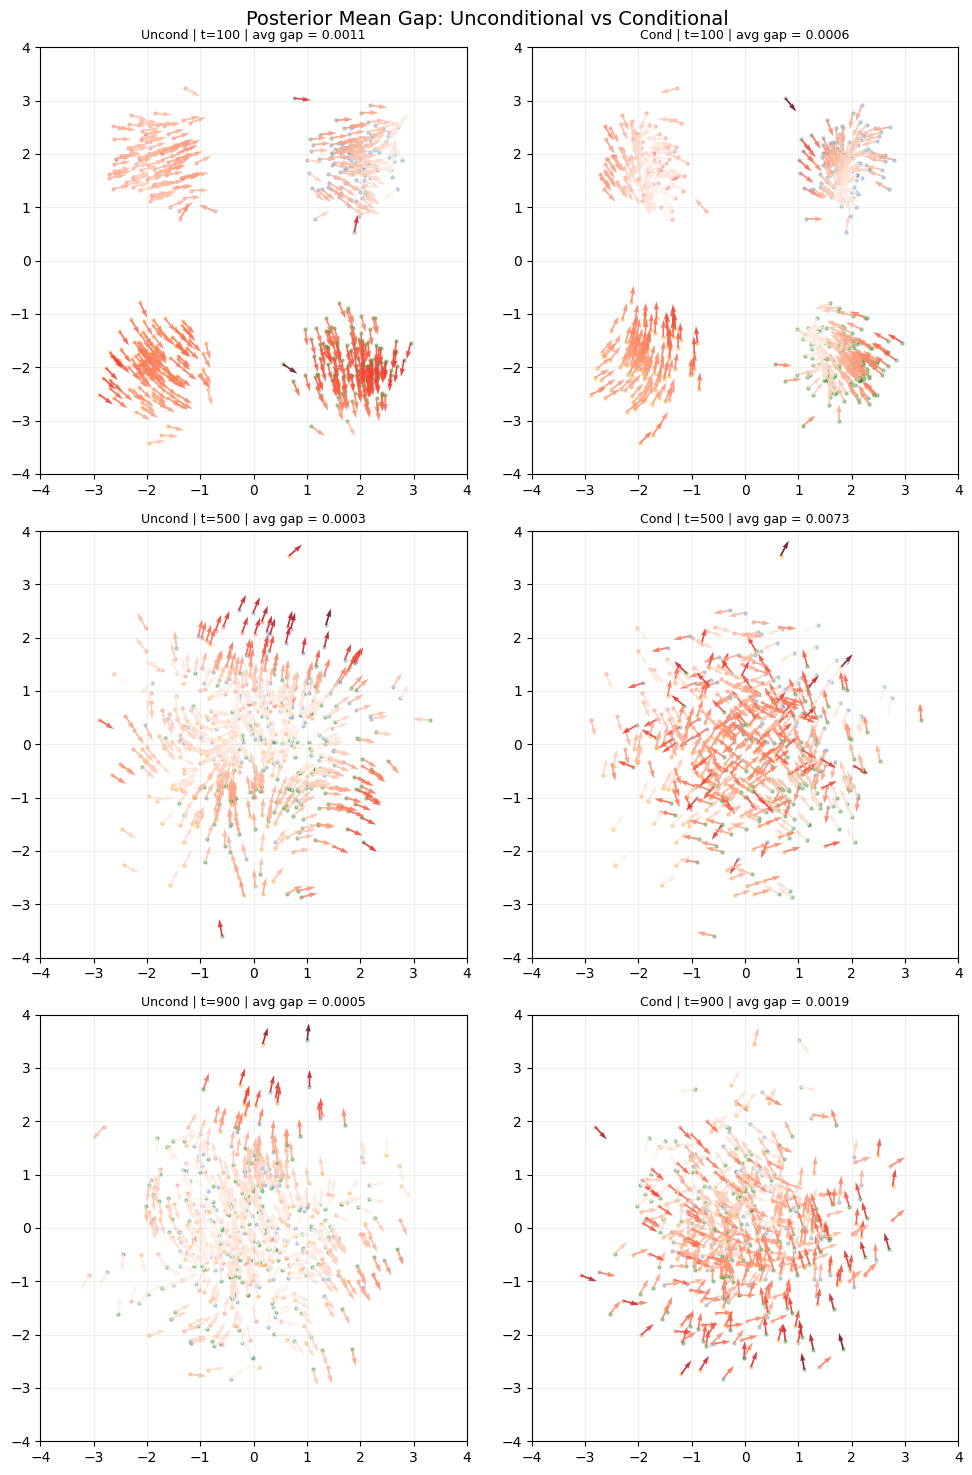

In [10]:
# Vector Field Plots

def plot_all_fields(model_uncond, model_cond,
                    data, labels, alpha_bar, betas):

    timesteps = [99, 499, 899]
    t_labels  = [100, 500, 900]

    x0_np = data[:500]
    labs  = labels[:500]
    x0_t  = torch.tensor(x0_np, dtype=torch.float32).to(device)

    c_onehot = torch.zeros(500, K, device=device)
    c_onehot.scatter_(
        1, torch.tensor(labs, device=device).unsqueeze(1), 1.0)

    # ── Fix: pre-sample ONE noise tensor per timestep ───────────────
    # Both uncond and cond will use the SAME x_t
    noise_per_t = {}
    for t_idx in timesteps:
        torch.manual_seed(t_idx)   # reproducible per timestep
        noise_per_t[t_idx] = torch.randn_like(x0_t)

    # ── Figure 1: True / Uncond Model / Gap ─────────────────────────
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    col_titles = ['True Posterior Mean',
                  'Model Posterior Mean (Uncond)',
                  'Gap (True − Model)']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight='bold')

    for row, t_idx in enumerate(timesteps):
        ab     = alpha_bar[t_idx].item()
        eps    = noise_per_t[t_idx]
        x_t    = (ab ** 0.5) * x0_t + ((1 - ab) ** 0.5) * eps
        x_t_np = x_t.cpu().numpy()

        mu_true  = true_posterior_mean_grid(
            x_t_np, t_idx, alpha_bar, betas)
        mu_model = model_posterior_mean_grid(
            model_uncond, x_t_np, t_idx, alpha_bar, betas)
        gap      = mu_true - mu_model

        v_true  = mu_true  - x_t_np
        v_model = mu_model - x_t_np

        for col, (u, v) in enumerate([
            (v_true[:, 0],  v_true[:, 1]),
            (v_model[:, 0], v_model[:, 1]),
            (gap[:, 0],     gap[:, 1])
        ]):
            ax = axes[row, col]
            for k in range(K):
                mask = labs == k
                ax.scatter(x_t_np[mask, 0], x_t_np[mask, 1],
                           s=5, alpha=0.3, color=COLORS[k])

            mag = np.sqrt(u**2 + v**2) + 1e-8
            ax.quiver(x_t_np[:, 0], x_t_np[:, 1],
                      u / mag, v / mag, mag,
                      cmap='plasma', alpha=0.85,
                      scale=25, width=0.004)

            ax.set_ylabel(f't = {t_labels[row]}', fontsize=10)
            ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.2)

    plt.suptitle('Posterior Mean Fields — Unconditional Model',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig('vector_fields_uncond.png', dpi=150)
    plt.show()

    # ── Figure 2: Gap comparison — same x_t for both ────────────────
    fig2, axes2 = plt.subplots(3, 2, figsize=(10, 15))
    axes2[0, 0].set_title('Gap — Unconditional',
                           fontsize=12, fontweight='bold')
    axes2[0, 1].set_title('Gap — Conditional',
                           fontsize=12, fontweight='bold')

    print("\nGap comparison (same x_t for both models):")
    print(f"{'Timestep':<12} {'Uncond Gap':>12} {'Cond Gap':>12} "
          f"{'Reduction':>12}")
    print("-" * 52)

    for row, t_idx in enumerate(timesteps):
        ab     = alpha_bar[t_idx].item()
        eps    = noise_per_t[t_idx]          # same noise for both
        x_t    = (ab ** 0.5) * x0_t + ((1 - ab) ** 0.5) * eps
        x_t_np = x_t.cpu().numpy()

        mu_true   = true_posterior_mean_grid(
            x_t_np, t_idx, alpha_bar, betas)
        mu_uncond = model_posterior_mean_grid(
            model_uncond, x_t_np, t_idx, alpha_bar, betas)
        mu_cond   = model_posterior_mean_grid(
            model_cond, x_t_np, t_idx, alpha_bar, betas,
            c=c_onehot)

        gap_u     = mu_true - mu_uncond
        gap_c     = mu_true - mu_cond

        avg_gap_u = np.mean(np.linalg.norm(gap_u, axis=1))
        avg_gap_c = np.mean(np.linalg.norm(gap_c, axis=1))
        reduction = (avg_gap_u - avg_gap_c) / avg_gap_u * 100

        print(f"t={t_labels[row]:<9} {avg_gap_u:>12.4f} "
              f"{avg_gap_c:>12.4f} {reduction:>11.1f}%")

        for col, gap in enumerate([gap_u, gap_c]):
            ax   = axes2[row, col]
            u, v = gap[:, 0], gap[:, 1]
            mag  = np.sqrt(u**2 + v**2) + 1e-8

            for k in range(K):
                mask = labs == k
                ax.scatter(x_t_np[mask, 0], x_t_np[mask, 1],
                           s=5, alpha=0.3, color=COLORS[k])

            ax.quiver(x_t_np[:, 0], x_t_np[:, 1],
                      u / mag, v / mag, mag,
                      cmap='Reds', alpha=0.85,
                      scale=25, width=0.004)

            label = 'Uncond' if col == 0 else 'Cond'
            val   = avg_gap_u if col == 0 else avg_gap_c
            ax.set_title(
                f'{label} | t={t_labels[row]} | avg gap = {val:.4f}',
                fontsize=9)
            ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.2)

    plt.suptitle('Posterior Mean Gap: Unconditional vs Conditional',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig('vector_fields_gap.png', dpi=150)
    plt.show()


plot_all_fields(model_uncond, model_cond,
                data, labels, alpha_bar, betas)

# What we are doing -

#### We have 4 clusters of points on a 2D plane. We add noise to them. At some timestep t, a noisy point x_t is floating somewhere in space. The question is:

#### "Where should this noisy point denoise toward?"

#### There are two ways to answer that:
#### Analytically (the true answer):
#### Look at x_t, figure out how likely it came from each of the 4 clusters, and return a weighted average direction. This is μ̃_t — the mathematically correct answer.
#### The model's answer:
#### The trained network looks at x_t and predicts where to denoise. This is μ_θ — what the model thinks.
#### The gap is just how wrong the model is compared to the true answer.

# Some personal notes


```
Naive conditioning (what we did):
→ Give the model a fixed label at ALL timesteps
→ Helps at low t where label is meaningful
→ Hurts badly at high t where label is noise

LDAE's solution:
→ The semantic embedding y_sem is only injected
   at timesteps where it is actually informative
→ At high t the model operates more like
   an unconditional model
→ The SNR weighting already told us high-t
   timesteps are low-information — this confirms it
   from the conditioning side too
```


Conditioning only closes the posterior mean gap if the conditioning signal is actually correct — which is why LDAE spends so much effort learning a good semantic embedding y_sem. A bad or approximate semantic embedding makes the gap worse, not better.



# Interpretation

#### The vector field plots show that at t=100 the true posterior mean and unconditional model posterior mean both point sharply toward individual cluster centres, with the gap field concentrated at cluster boundaries where the model is uncertain about which cluster a point belongs to. At t=500 and t=900 both fields converge toward the origin as the cluster structure is destroyed by noise — the unconditional model correctly learns this behaviour, producing a very small gap. The gap comparison table confirms that naive class conditioning reduces the gap by 44.9% at t=100 where the label is genuinely informative, but increases it by over 2000% at t=500 and nearly 300% at t=900 — because at high noise levels the true posterior no longer differentiates between clusters while the conditional model confidently denoises toward the labelled cluster regardless. This result directly motivates LDAE's architecture: a fixed class label injected uniformly across all timesteps is harmful at high t where cluster identity is unrecoverable, which is why LDAE learns a continuous semantic embedding y_sem that interacts with the SNR-weighted loss to naturally emphasise conditioning at low-t timesteps where the signal is intact and suppress it at high-t timesteps where it becomes misleading. The posterior mean gap is therefore not just a measure of model quality — it is the precise diagnostic that reveals when and why conditioning helps or hurts, and LDAE's design is a direct engineering response to the pattern seen in these three timesteps.

# More personal understanding notes -->

### At t=100 — Low Noise, Clusters Still Visible

The noisy points still carry enough signal that you can tell which cluster they came from. The true posterior knows "this point is near cluster 2, denoise toward cluster 2." The conditional model receives the correct label and agrees. The unconditional model has to guess — and sometimes guesses wrong. So conditioning reduces the gap.

x_t at t=100 still looks like the original cluster

→ label is informative

→ conditioning helps


### At t=500 and t=900 — High Noise, Clusters Destroyed

The noisy points are now scattered far from their original clusters — they're essentially random Gaussian noise. The true posterior at this noise level says "everything should point roughly toward the origin, cluster identity is irrelevant because you can't recover it from this much noise."

The unconditional model has learned exactly this — it points toward the origin and gets close to the true answer. Gap is tiny.

The conditional model receives a cluster label and thinks "I know this came from cluster 2, I should denoise toward cluster 2." But cluster 2 might be at (2,2) and the noisy point is currently at (−1, 0.5) — nowhere near it. The model confidently pulls in the wrong direction. Gap explodes.

x_t at t=500 looks like pure noise — no cluster structure

→ label is misleading not informative

→ conditioning hurts

→ model is confidently wrong
